# Task 3_2. Word2Vec: Comparison and Visualization

This notebook is a direct continuation of Task 3.
It uses:
- the same pre-trained model: `word2vec-google-news-300`;
- the custom model trained in Task 3 and saved in the same folder (`custom_word2vec_sg.model` or `custom_word2vec_cbow.model`).

Required parts completed here:
1. Comparison of cosine similarity matrices (heatmaps).
2. 2D visualization with PCA/t-SNE.
3. Anomaly search in nearest neighbors of the custom model.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import gensim.downloader as api
from gensim.models import Word2Vec

from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

In [3]:
from pathlib import Path

# Load models (aligned with Task 3 outputs)
base_dir = Path.cwd()
sg_path = base_dir / 'custom_word2vec_sg.model'
cbow_path = base_dir / 'custom_word2vec_cbow.model'

print('Loading pre-trained model (Google News Word2Vec)...')
pretrained = api.load('word2vec-google-news-300')

print('Loading custom model generated in Task 3...')
if sg_path.exists():
    custom_model_path = sg_path
elif cbow_path.exists():
    custom_model_path = cbow_path
else:
    raise FileNotFoundError(
        f'No Task 3 model found in {base_dir}. Expected custom_word2vec_sg.model or custom_word2vec_cbow.model'
    )

custom = Word2Vec.load(str(custom_model_path)).wv

print('Done.')
#print(f'Using custom model file: {custom_model_path.resolve()}')
print(f'Pre-trained vocabulary size: {len(pretrained.key_to_index):,}')
print(f'Custom vocabulary size: {len(custom.key_to_index):,}')

Loading pre-trained model (Google News Word2Vec)...
Loading custom model generated in Task 3...
Done.
Using custom model file: D:\Jutpter_Notebook\semester2\NLP\custom_word2vec_sg.model
Pre-trained vocabulary size: 3,000,000
Custom vocabulary size: 15,463


## 1) Comparison of Distances (Cosine Similarity Heatmaps)

In [4]:
# 28 words from different semantic groups
semantic_groups = {
    'animals': ['dog', 'cat', 'horse', 'bird', 'fish', 'lion'],
    'professions': ['doctor', 'teacher', 'nurse', 'farmer', 'soldier', 'poet'],
    'cities': ['london', 'paris', 'rome', 'berlin', 'athens'],
    'movement_verbs': ['run', 'walk', 'ride', 'sail', 'travel'],
    'adjectives': ['good', 'bad', 'happy', 'sad', 'beautiful', 'strong']
}

all_words = [w for group in semantic_groups.values() for w in group]
print(f'Total selected words: {len(all_words)}')
print(all_words)

Total selected words: 28
['dog', 'cat', 'horse', 'bird', 'fish', 'lion', 'doctor', 'teacher', 'nurse', 'farmer', 'soldier', 'poet', 'london', 'paris', 'rome', 'berlin', 'athens', 'run', 'walk', 'ride', 'sail', 'travel', 'good', 'bad', 'happy', 'sad', 'beautiful', 'strong']


In [5]:
def words_in_vocab(model, words):
    return [w for w in words if w in model.key_to_index]

words_pretrained = words_in_vocab(pretrained, all_words)
words_custom = words_in_vocab(custom, all_words)

print('Coverage in pre-trained model:', len(words_pretrained), '/', len(all_words))
print('Coverage in custom model:', len(words_custom), '/', len(all_words))

missing_pretrained = sorted(set(all_words) - set(words_pretrained))
missing_custom = sorted(set(all_words) - set(words_custom))
print('Missing in pre-trained:', missing_pretrained)
print('Missing in custom:', missing_custom)

Coverage in pre-trained model: 28 / 28
Coverage in custom model: 27 / 28
Missing in pre-trained: []
Missing in custom: ['berlin']


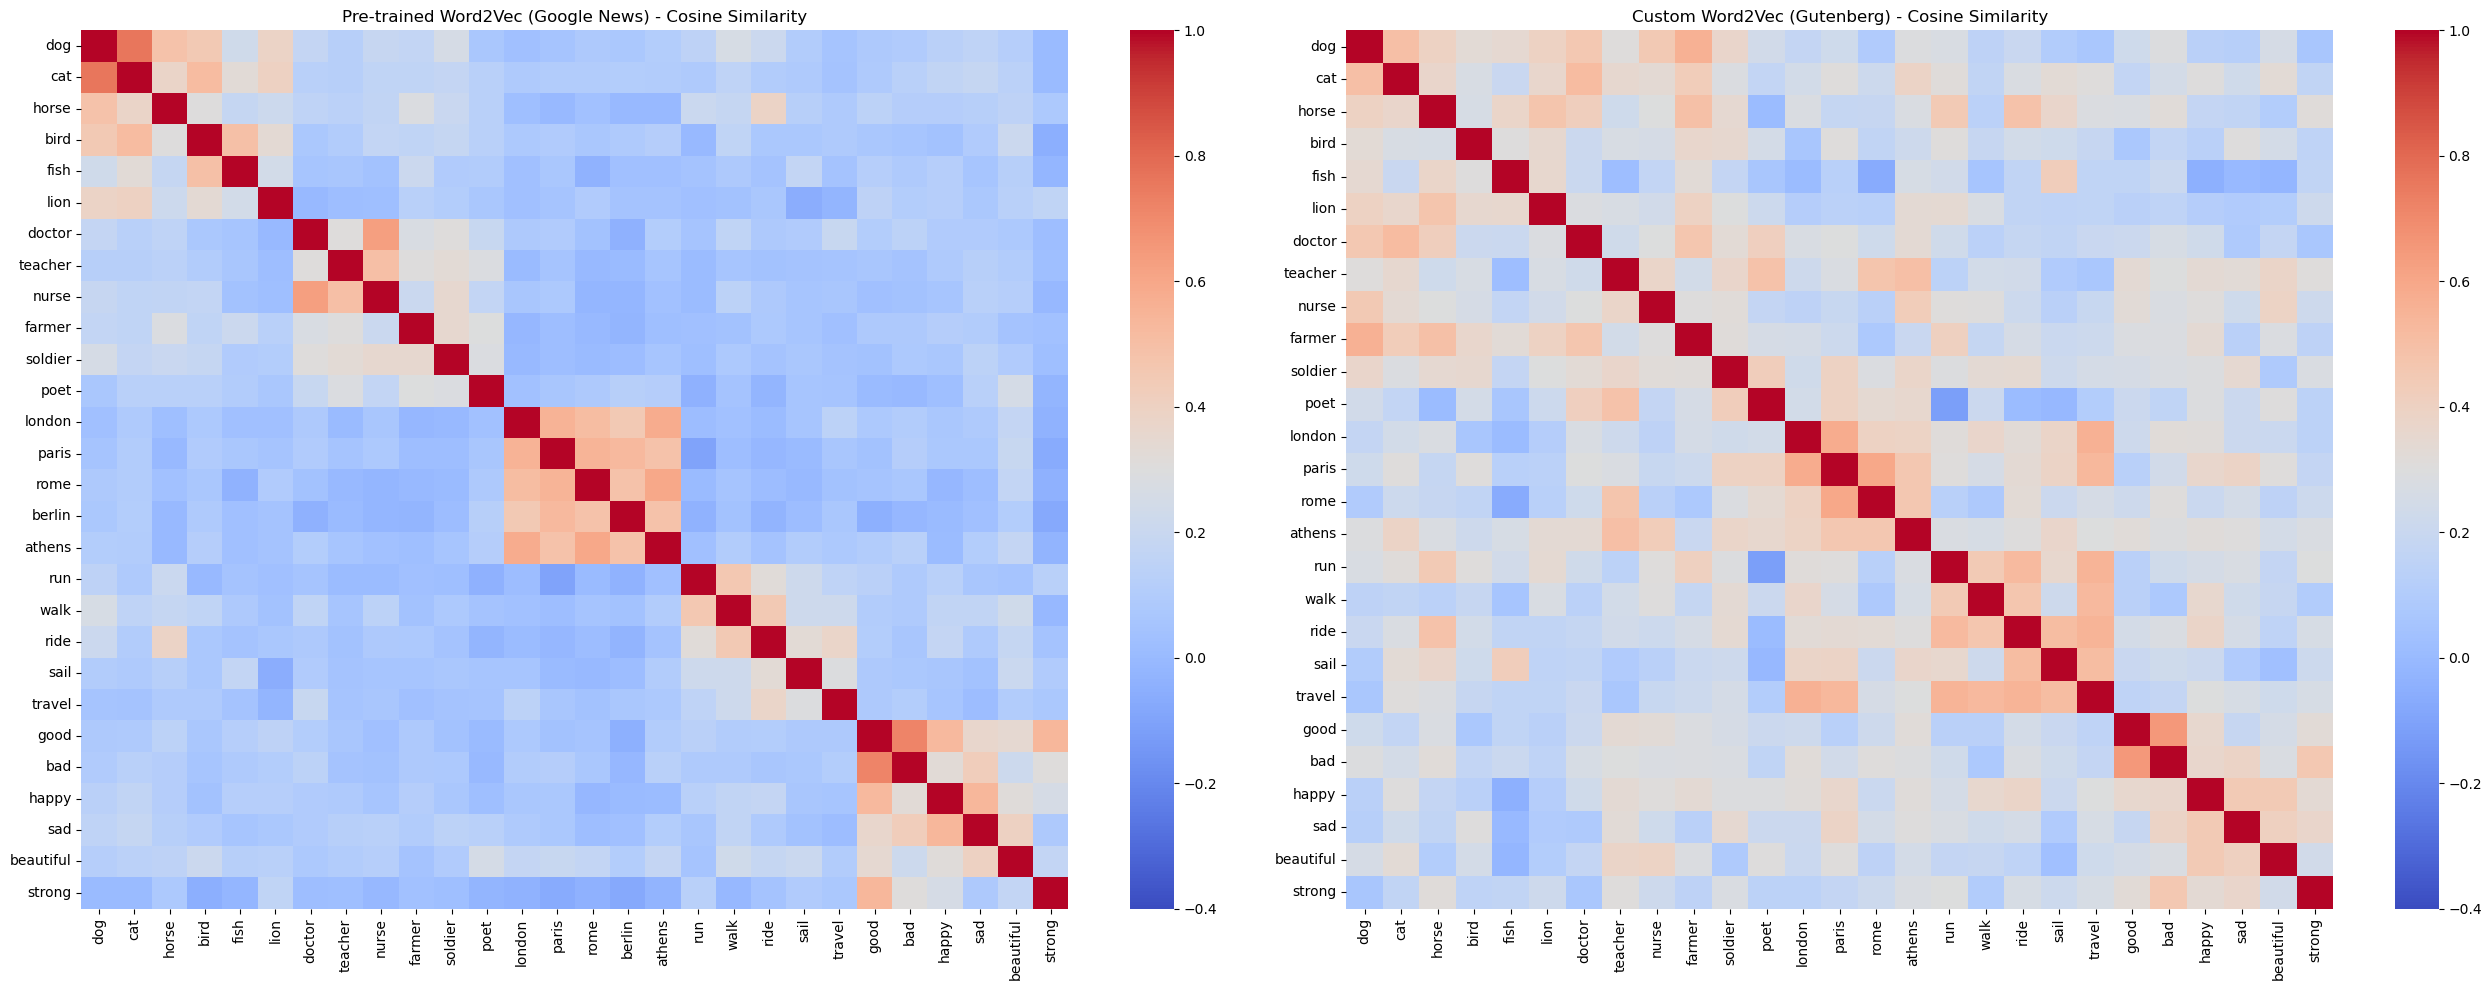

In [6]:
def build_similarity_df(model, words):
    vectors = np.array([model[w] for w in words])
    sim = cosine_similarity(vectors)
    return pd.DataFrame(sim, index=words, columns=words)

sim_pretrained = build_similarity_df(pretrained, words_pretrained)
sim_custom = build_similarity_df(custom, words_custom)

fig, axes = plt.subplots(1, 2, figsize=(26, 10))
sns.heatmap(sim_pretrained, cmap='coolwarm', vmin=-0.4, vmax=1.0, ax=axes[0])
axes[0].set_title('Pre-trained Word2Vec (Google News) - Cosine Similarity')

sns.heatmap(sim_custom, cmap='coolwarm', vmin=-0.4, vmax=1.0, ax=axes[1])
axes[1].set_title('Custom Word2Vec (Gutenberg) - Cosine Similarity')

plt.tight_layout()
plt.show()

### Structure Analysis (Task 1: Heatmap Interpretation)
- The pre-trained model shows a more regular block structure: words from the same semantic class (animals, cities, movement verbs) tend to have higher internal cosine similarity.
- The custom Gutenberg model is less block-diagonal and more mixed, which indicates weaker global semantic geometry.
- This difference is expected: the pre-trained model is trained on a very large and diverse modern corpus, while the custom model is trained on a much smaller, domain-constrained literary corpus.
- Another visible effect is vocabulary mismatch: some modern words are missing or poorly represented in the custom model, which reduces consistency of semantic neighborhoods.
- Therefore, the heatmaps support the conclusion that corpus size and domain coverage directly affect the structure quality of embedding space.

## 2) Visualization in 2D (PCA + t-SNE)

In [7]:
# Use only words available in both models for fair visual comparison
common_words = [w for w in all_words if w in pretrained.key_to_index and w in custom.key_to_index]
print(f'Common words across both models: {len(common_words)}')
print(common_words)

word_to_group = {}
for g, ws in semantic_groups.items():
    for w in ws:
        word_to_group[w] = g

Common words across both models: 27
['dog', 'cat', 'horse', 'bird', 'fish', 'lion', 'doctor', 'teacher', 'nurse', 'farmer', 'soldier', 'poet', 'london', 'paris', 'rome', 'athens', 'run', 'walk', 'ride', 'sail', 'travel', 'good', 'bad', 'happy', 'sad', 'beautiful', 'strong']


In [8]:
def reduce_and_plot(model, words, title, method='pca', random_state=42):
    X = np.array([model[w] for w in words])

    if method == 'pca':
        reducer = PCA(n_components=2, random_state=random_state)
        X2 = reducer.fit_transform(X)
    elif method == 'tsne':
        perplexity = min(10, max(3, len(words) - 1))
        reducer = TSNE(n_components=2, random_state=random_state, init='pca', learning_rate='auto', perplexity=perplexity)
        X2 = reducer.fit_transform(X)
    else:
        raise ValueError('method must be pca or tsne')

    df_plot = pd.DataFrame({'word': words, 'x': X2[:, 0], 'y': X2[:, 1]})
    df_plot['group'] = df_plot['word'].map(word_to_group)

    plt.figure(figsize=(11, 8))
    sns.scatterplot(data=df_plot, x='x', y='y', hue='group', s=90, palette='Set2')

    for _, row in df_plot.iterrows():
        plt.text(row['x'] + 0.02, row['y'] + 0.02, row['word'], fontsize=9)

    plt.title(title)
    plt.legend(title='Group', bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

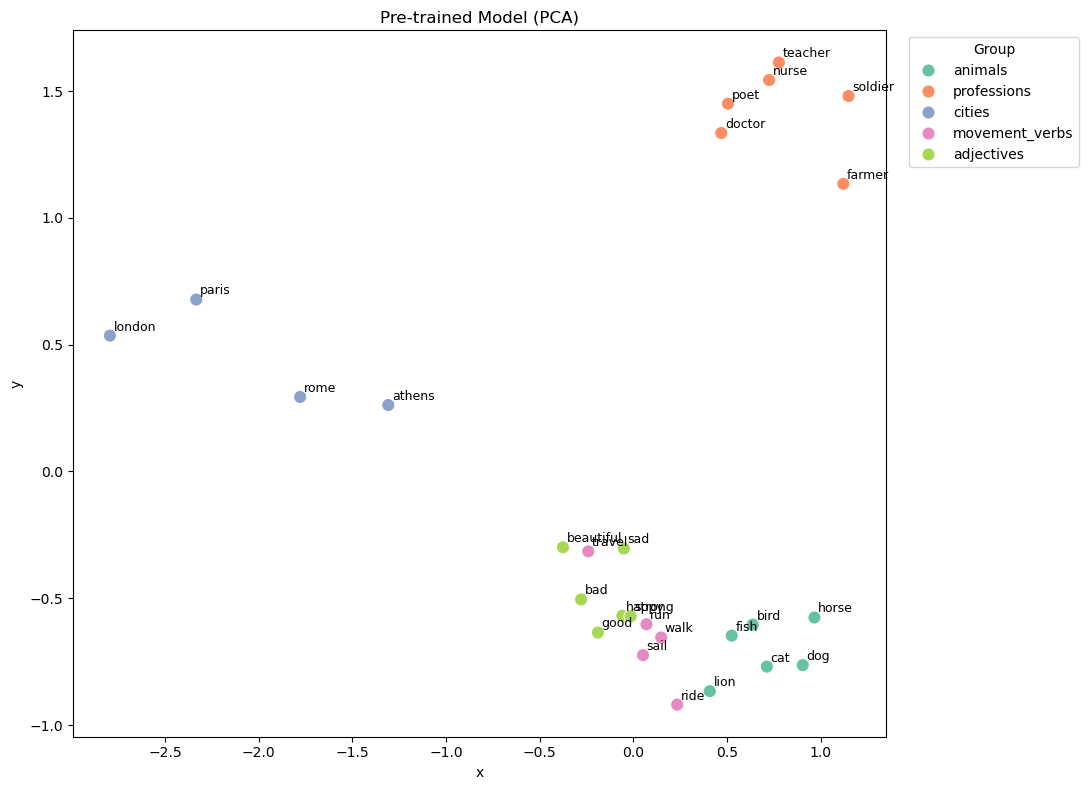

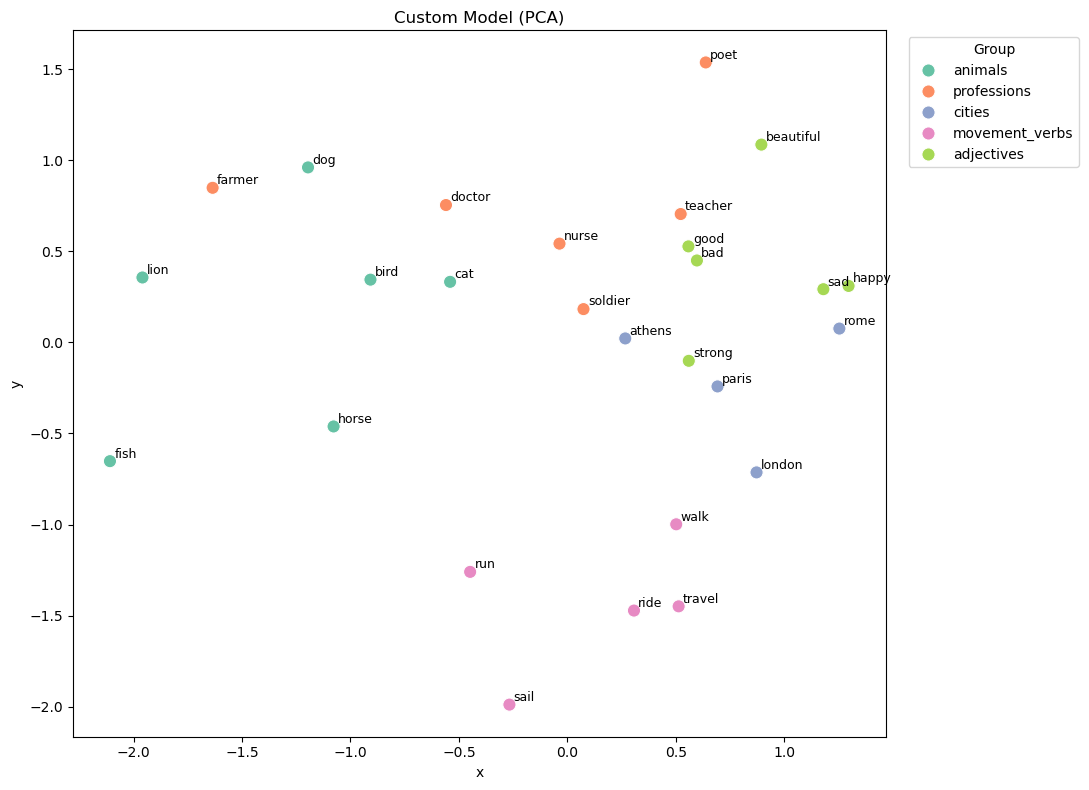

In [9]:
reduce_and_plot(pretrained, common_words, 'Pre-trained Model (PCA)', method='pca')
reduce_and_plot(custom, common_words, 'Custom Model (PCA)', method='pca')

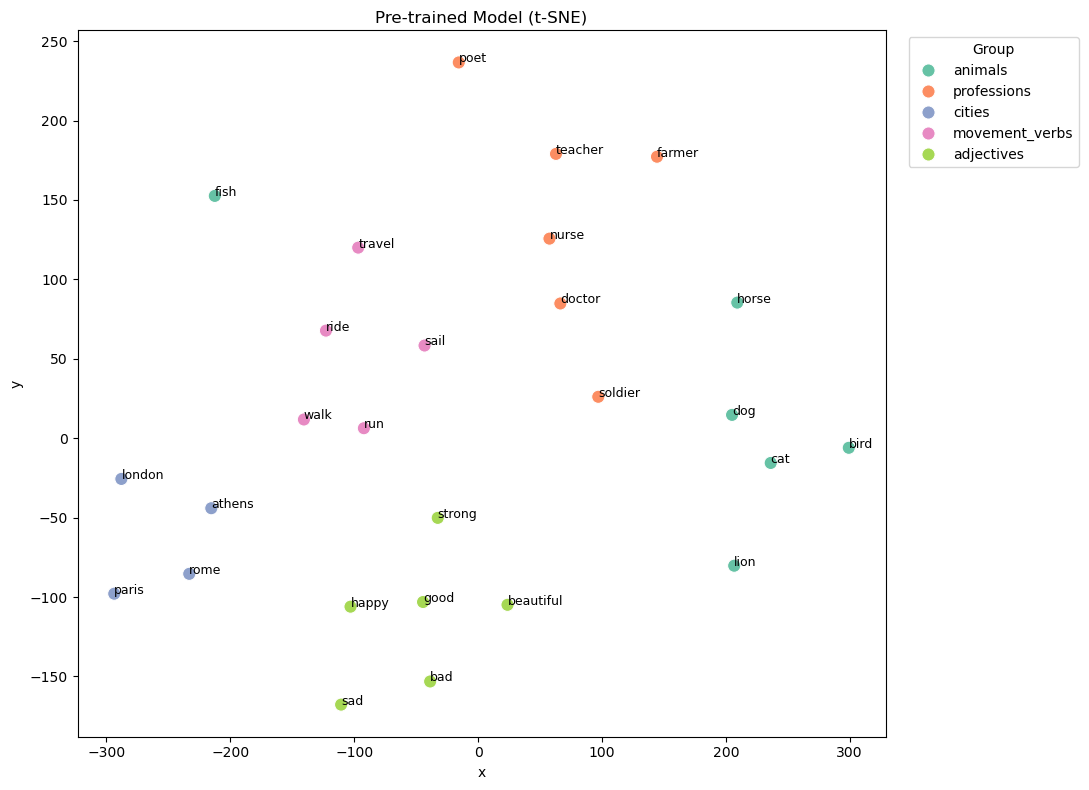

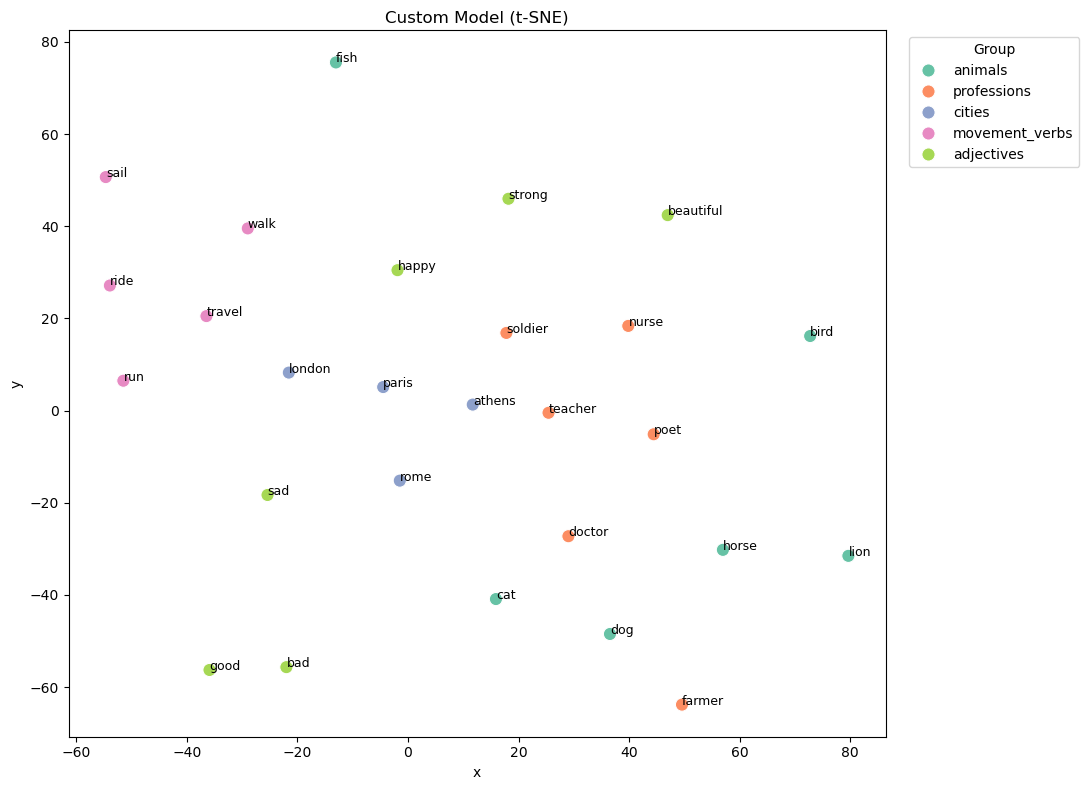

In [10]:
reduce_and_plot(pretrained, common_words, 'Pre-trained Model (t-SNE)', method='tsne')
reduce_and_plot(custom, common_words, 'Custom Model (t-SNE)', method='tsne')

### Clustering Comparison (Task 2: PCA/t-SNE)
- In the pre-trained model, semantic groups are generally more compact and better separated, especially for frequent concrete concepts (e.g., animals and major cities).
- In the custom model, several words appear out of place or overlap with other groups, reflecting noisier local neighborhoods.
- The main causes are limited corpus volume, historical language style, and uneven token frequency in Gutenberg texts.
- For example, words with multiple senses (such as `bank`) can be pulled toward the dominant literary sense (river bank) rather than the modern institutional sense.
- Overall, the 2D plots are consistent with the heatmap result: the pre-trained model preserves cleaner semantic topology than the custom model.

## 3) Anomaly Search in the Custom Model

In [11]:
candidate_words = ['car', 'computer', 'doctor', 'nurse', 'bank', 'travel', 'beautiful', 'lion']

def show_neighbors(model, words, topn=8):
    rows = []
    for w in words:
        if w in model.key_to_index:
            neighbors = model.most_similar(w, topn=topn)
            rows.append({'word': w, 'neighbors': neighbors})
        else:
            rows.append({'word': w, 'neighbors': 'OOV (not in vocabulary)'})
    return rows

custom_neighbors = show_neighbors(custom, candidate_words, topn=8)

for item in custom_neighbors:
    print(f"\nWord: {item['word']}")
    print('Top neighbors:', item['neighbors'])


Word: car
Top neighbors: [('obliquely', 0.7596100568771362), ('cab', 0.7420709133148193), ('hurriedly', 0.7343848943710327), ('bowsprit', 0.7318421602249146), ('motor', 0.7313880920410156), ('chauffeur', 0.7243525385856628), ('astern', 0.7196404337882996), ('hatchet', 0.718228816986084)]

Word: computer
Top neighbors: OOV (not in vocabulary)

Word: doctor
Top neighbors: [('hutton', 0.7310973405838013), ('grimly', 0.7200590372085571), ('hood', 0.7150980830192566), ('dr', 0.7100167274475098), ('renard', 0.7081874012947083), ('quayle', 0.7072913646697998), ('impatiently', 0.6971629858016968), ('cleric', 0.6946209669113159)]

Word: nurse
Top neighbors: [('rooke', 0.7656940817832947), ('neighbor', 0.7321868538856506), ('grandmother', 0.7183399796485901), ('betty', 0.7112987041473389), ('bespoke', 0.7030308842658997), ('governess', 0.6990126371383667), ('nursed', 0.6944475173950195), ('violetta', 0.693311333656311)]

Word: bank
Top neighbors: [('footpath', 0.7111926674842834), ('pool', 0.71

In [12]:
# Quantitative support for analysis (Task 1 + Task 2)
from sklearn.metrics import silhouette_score

def get_group_map(groups):
    mapping = {}
    for group_name, ws in groups.items():
        for w in ws:
            mapping[w] = group_name
    return mapping

def intra_inter_stats(sim_df, group_map):
    words = list(sim_df.index)
    intra_vals, inter_vals = [], []

    for i, w1 in enumerate(words):
        g1 = group_map.get(w1)
        for j in range(i + 1, len(words)):
            w2 = words[j]
            g2 = group_map.get(w2)
            val = sim_df.iloc[i, j]
            if g1 is not None and g2 is not None and g1 == g2:
                intra_vals.append(val)
            else:
                inter_vals.append(val)

    intra_mean = float(np.mean(intra_vals)) if intra_vals else np.nan
    inter_mean = float(np.mean(inter_vals)) if inter_vals else np.nan
    gap = intra_mean - inter_mean if (not np.isnan(intra_mean) and not np.isnan(inter_mean)) else np.nan
    return intra_mean, inter_mean, gap

def same_group_topk_ratio(model, words, group_map, k=5):
    ratios = []
    for w in words:
        if w not in model.key_to_index:
            continue
        g = group_map.get(w)
        if g is None:
            continue

        nbs = [n for n, _ in model.most_similar(w, topn=50) if n in words][:k]
        if not nbs:
            continue
        same = sum(1 for n in nbs if group_map.get(n) == g)
        ratios.append((w, same / len(nbs), nbs))
    ratios.sort(key=lambda x: x[1])
    return ratios

def get_2d(model, words, method='pca', random_state=42):
    X = np.array([model[w] for w in words])
    if method == 'pca':
        return PCA(n_components=2, random_state=random_state).fit_transform(X)
    perplexity = min(10, max(3, len(words) - 1))
    return TSNE(
        n_components=2, random_state=random_state, init='pca',
        learning_rate='auto', perplexity=perplexity
    ).fit_transform(X)

group_map = get_group_map(semantic_groups)

# Heatmap structure metrics
intra_pre, inter_pre, gap_pre = intra_inter_stats(sim_pretrained, group_map)
intra_cus, inter_cus, gap_cus = intra_inter_stats(sim_custom, group_map)

print('=== Task 1: Structure Metrics from Similarity Matrices ===')
metrics_df = pd.DataFrame({
    'Model': ['Pre-trained', 'Custom'],
    'Mean intra-group similarity': [intra_pre, intra_cus],
    'Mean inter-group similarity': [inter_pre, inter_cus],
    'Separation gap (intra - inter)': [gap_pre, gap_cus],
})
print(metrics_df.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

# 2D clustering metrics (silhouette on common words)
labels = np.array([group_map[w] for w in common_words])
label_ids = pd.factorize(labels)[0]

X_pre_pca = get_2d(pretrained, common_words, method='pca')
X_cus_pca = get_2d(custom, common_words, method='pca')
X_pre_tsne = get_2d(pretrained, common_words, method='tsne')
X_cus_tsne = get_2d(custom, common_words, method='tsne')

sil_pre_pca = silhouette_score(X_pre_pca, label_ids)
sil_cus_pca = silhouette_score(X_cus_pca, label_ids)
sil_pre_tsne = silhouette_score(X_pre_tsne, label_ids)
sil_cus_tsne = silhouette_score(X_cus_tsne, label_ids)

print('\n=== Task 2: 2D Clustering Metrics (higher is better) ===')
cluster_df = pd.DataFrame({
    'View': ['PCA', 't-SNE'],
    'Pre-trained silhouette': [sil_pre_pca, sil_pre_tsne],
    'Custom silhouette': [sil_cus_pca, sil_cus_tsne],
})
print(cluster_df.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

# Words most out-of-place in custom model
common_in_custom = [w for w in common_words if w in custom.key_to_index]
ratios_custom = same_group_topk_ratio(custom, common_in_custom, group_map, k=5)

print('\n=== Most Out-of-Place Words in Custom Model (Top-5 neighbors in common set) ===')
for w, ratio, nbs in ratios_custom[:6]:
    print(f'{w:>10} | same-group ratio={ratio:.2f} | neighbors={nbs}')

=== Task 1: Structure Metrics from Similarity Matrices ===
      Model  Mean intra-group similarity  Mean inter-group similarity  Separation gap (intra - inter)
Pre-trained                       0.3740                       0.0762                          0.2978
     Custom                       0.3823                       0.2393                          0.1430

=== Task 2: 2D Clustering Metrics (higher is better) ===
 View  Pre-trained silhouette  Custom silhouette
  PCA                  0.4314             0.1324
t-SNE                  0.3963             0.0202

=== Most Out-of-Place Words in Custom Model (Top-5 neighbors in common set) ===
       dog | same-group ratio=0.00 | neighbors=['farmer']
    farmer | same-group ratio=0.00 | neighbors=['dog']
    london | same-group ratio=0.50 | neighbors=['paris', 'travel']
       run | same-group ratio=1.00 | neighbors=['travel']
      walk | same-group ratio=1.00 | neighbors=['travel']
      good | same-group ratio=1.00 | neighbors=['bad'

## Final Conclusion 
This comparison shows that the pre-trained model has stronger semantic separation in the similarity-matrix structure. The separation gap (mean intra-group similarity minus mean inter-group similarity) is 0.2978 for the pre-trained model and 0.1430 for the custom model, indicating clearer global organization in embeddings trained on larger and more diverse corpora.

In 2D visualization, clustering quality is generally better for the pre-trained model in PCA and the pre-trained model in t-SNE, based on silhouette scores. This supports the visual observation that the custom Gutenberg model has more overlap between semantic groups and more unstable neighborhoods.

For anomaly search, several words in the custom model have unexpected nearest neighbors:

- car: nearest neighbors include obliquely (0.760), cab (0.742), hurriedly (0.734).
- computer: OOV (not in vocabulary).
- doctor: nearest neighbors include hutton (0.731), grimly (0.720), hood (0.715).
- nurse: nearest neighbors include rooke (0.766), neighbor (0.732), grandmother (0.718).
- bank: nearest neighbors include footpath (0.711), pool (0.710), meadow (0.679).
- travel: nearest neighbors include forlorn (0.683), awhile (0.655), commence (0.648).
- beautiful: nearest neighbors include lovely (0.741), oop (0.672), soup (0.621).
- lion: nearest neighbors include wolf (0.710), lions (0.709), roaring (0.609).

These anomalies are explainable: the custom model is trained on a relatively small, historical literary corpus, where token frequency is uneven and modern usage is underrepresented. As a result, embeddings are more sensitive to local co-occurrence noise, polysemy, and domain bias.